In [12]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from PIL import Image

# Global Configuration
CONFIG = {
    'train_csv': '/content/drive/MyDrive/Dataset/Hackathon/train_metadata.csv',       # Metadata with 7,854 training samples
    'eval_csv': '/content/drive/MyDrive/Dataset/Hackathon/test_metadata.csv',         # Metadata with 2,000 evaluation samples
    'train_img_dir': '/content/drive/MyDrive/Dataset/Hackathon/train_images/train_images',       # Directory containing training images
    'eval_img_dir': '/content/drive/MyDrive/Dataset/Hackathon/eval_images/eval_images',         # Directory containing evaluation images
    'img_size': (224, 224),
    'batch_size': 32,
    'epochs': 10,
    'lr': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Running on device: {CONFIG['device']}")

Running on device: cuda


In [13]:
def rotate_image(image, angle):
    """
    Rotates an image counter-clockwise by -sun_azimuth_angle
    to normalize lighting across all dataset images.
    """
    return image.rotate(-angle, expand=True)

class PareidoliaDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_eval=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_eval = is_eval

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id']
        img_path = os.path.join(self.img_dir, img_name)

        # Load grayscale/RGB image
        image = Image.open(img_path).convert('RGB')

        # Apply illumination normalization via metadata angle
        if 'sun_azimuth_angle' in row and pd.notnull(row['sun_azimuth_angle']):
            image = rotate_image(image, row['sun_azimuth_angle'])

        if self.transform:
            image = self.transform(image)

        if not self.is_eval:
            label = torch.tensor(row['label'], dtype=torch.long)
            return image, label

        return image, img_name

In [14]:
# Image Transformations
train_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Read Metadata CSVs
train_df = pd.read_csv(CONFIG['train_csv'])
eval_df = pd.read_csv(CONFIG['eval_csv'])

# Stratified Validation Split
train_data, val_data = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df['label']
)

# PyTorch DataLoaders
train_loader = DataLoader(
    PareidoliaDataset(train_data, CONFIG['train_img_dir'], train_transform),
    batch_size=CONFIG['batch_size'],
    shuffle=True
)

val_loader = DataLoader(
    PareidoliaDataset(val_data, CONFIG['train_img_dir'], eval_transform),
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

# ResNet50 Classifier Model Setup
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (0 or 1)
model = model.to(CONFIG['device'])

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])

for epoch in range(CONFIG['epochs']):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Evaluate Validation Performance
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(CONFIG['device'])
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            val_preds.extend(preds)
            val_targets.extend(labels.numpy())

    b_acc = balanced_accuracy_score(val_targets, val_preds)
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] - Loss: {running_loss/len(train_loader):.4f} - Val Balanced Accuracy: {b_acc:.4f}")

Epoch [1/10] - Loss: 0.6208 - Val Balanced Accuracy: 0.5418
Epoch [2/10] - Loss: 0.5920 - Val Balanced Accuracy: 0.6070
Epoch [3/10] - Loss: 0.5686 - Val Balanced Accuracy: 0.5977
Epoch [4/10] - Loss: 0.5354 - Val Balanced Accuracy: 0.5839
Epoch [5/10] - Loss: 0.4824 - Val Balanced Accuracy: 0.5878
Epoch [6/10] - Loss: 0.4189 - Val Balanced Accuracy: 0.5699
Epoch [7/10] - Loss: 0.3372 - Val Balanced Accuracy: 0.6015
Epoch [8/10] - Loss: 0.2590 - Val Balanced Accuracy: 0.6138
Epoch [9/10] - Loss: 0.2014 - Val Balanced Accuracy: 0.5926
Epoch [10/10] - Loss: 0.1513 - Val Balanced Accuracy: 0.5620


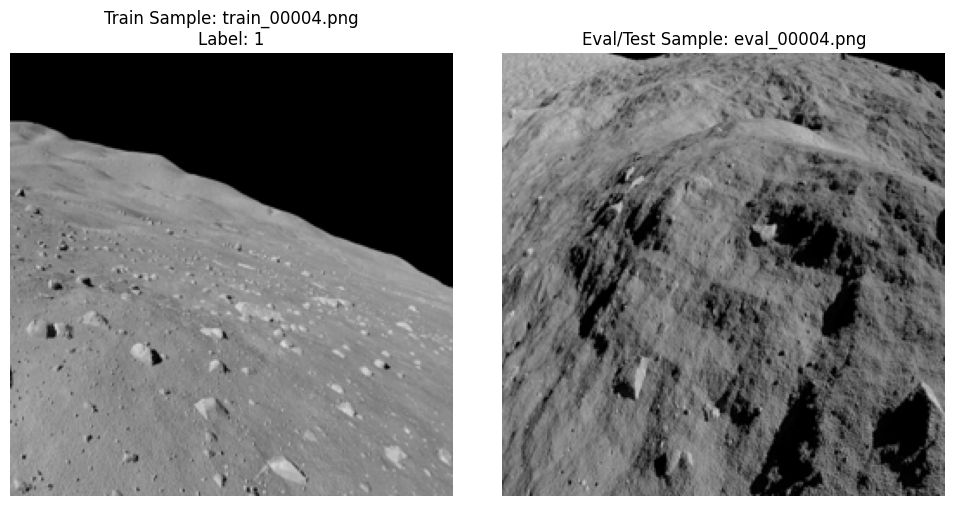

In [18]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Get the first image name from training and evaluation metadata
sample_train_name = train_df.iloc[3]['image_id']
sample_eval_name = eval_df.iloc[3]['image_id']

# Construct full paths
train_img_path = os.path.join(CONFIG['train_img_dir'], sample_train_name)
eval_img_path = os.path.join(CONFIG['eval_img_dir'], sample_eval_name)

# Open images
train_img = Image.open(train_img_path)
eval_img = Image.open(eval_img_path)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(train_img)
axes[0].set_title(f"Train Sample: {sample_train_name}\nLabel: {train_df.iloc[0]['label']}")
axes[0].axis('off')

axes[1].imshow(eval_img)
axes[1].set_title(f"Eval/Test Sample: {sample_eval_name}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [19]:
eval_loader = DataLoader(
    PareidoliaDataset(eval_df, CONFIG['eval_img_dir'], transform=eval_transform, is_eval=True),
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

model.eval()
submission_results = []

with torch.no_grad():
    for images, img_names in eval_loader:
        images = images.to(CONFIG['device'])
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        for name, pred in zip(img_names, preds):
            submission_results.append({'image_id': name, 'label': pred})

# Generate and verify submission output CSV
submission_df = pd.DataFrame(submission_results)
submission_df.to_csv('submission.csv', index=False)

print("Saved submission.csv successfully!")
print("Submission Shape:", submission_df.shape)  # Output shape: (2000, 2)
print(submission_df.head())

Saved submission.csv successfully!
Submission Shape: (2000, 2)
         image_id  label
0  eval_00001.png      1
1  eval_00002.png      1
2  eval_00003.png      0
3  eval_00004.png      1
4  eval_00005.png      0
